<a href="https://colab.research.google.com/github/ramnoa/Brain-Tumor-Model/blob/main/Braintumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install tensorflow

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications import MobileNetV2
import warnings
warnings.filterwarnings('ignore')


In [17]:
import os
import json

# PASTE YOUR DATA FROM THE JSON FILE HERE
data = {
    "username": "Brain",
    "key": "KGAT_f7d826ba48cb4b7a88fe5a7380e83d32"
}

# This creates the folder and the file correctly
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(data, f)

!chmod 600 ~/.kaggle/kaggle.json
print("✅ Credentials manually created!")


✅ Credentials manually created!


In [18]:
# Use this dataset link instead
!kaggle datasets download -d sartajbhuvaji/brain-tumor-classification-mri
!unzip brain-tumor-classification-mri.zip


Dataset URL: https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri
License(s): MIT
  0% 0.00/86.8M [00:00<?, ?B/s]
100% 86.8M/86.8M [00:00<00:00, 1.74GB/s]
Archive:  brain-tumor-classification-mri.zip
  inflating: Testing/glioma_tumor/image(1).jpg  
  inflating: Testing/glioma_tumor/image(10).jpg  
  inflating: Testing/glioma_tumor/image(100).jpg  
  inflating: Testing/glioma_tumor/image(11).jpg  
  inflating: Testing/glioma_tumor/image(12).jpg  
  inflating: Testing/glioma_tumor/image(13).jpg  
  inflating: Testing/glioma_tumor/image(14).jpg  
  inflating: Testing/glioma_tumor/image(15).jpg  
  inflating: Testing/glioma_tumor/image(16).jpg  
  inflating: Testing/glioma_tumor/image(17).jpg  
  inflating: Testing/glioma_tumor/image(18).jpg  
  inflating: Testing/glioma_tumor/image(19).jpg  
  inflating: Testing/glioma_tumor/image(2).jpg  
  inflating: Testing/glioma_tumor/image(20).jpg  
  inflating: Testing/glioma_tumor/image(21).jpg  
  inflating: Testing/glioma

In [19]:
from tensorflow.keras.utils import image_dataset_from_directory

# Setting the paths based on your successful unzip
train_dir = '/content/Training'
test_dir = '/content/Testing'

# Load the training dataset
train_ds = image_dataset_from_directory(
    train_dir,
    image_size=(224, 224), # or whatever size your model uses
    batch_size=32,
    label_mode='categorical'
)

# Load the testing dataset
test_ds = image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

print(f"Detected Classes: {train_ds.class_names}")



Found 2870 files belonging to 4 classes.
Found 394 files belonging to 4 classes.
Detected Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


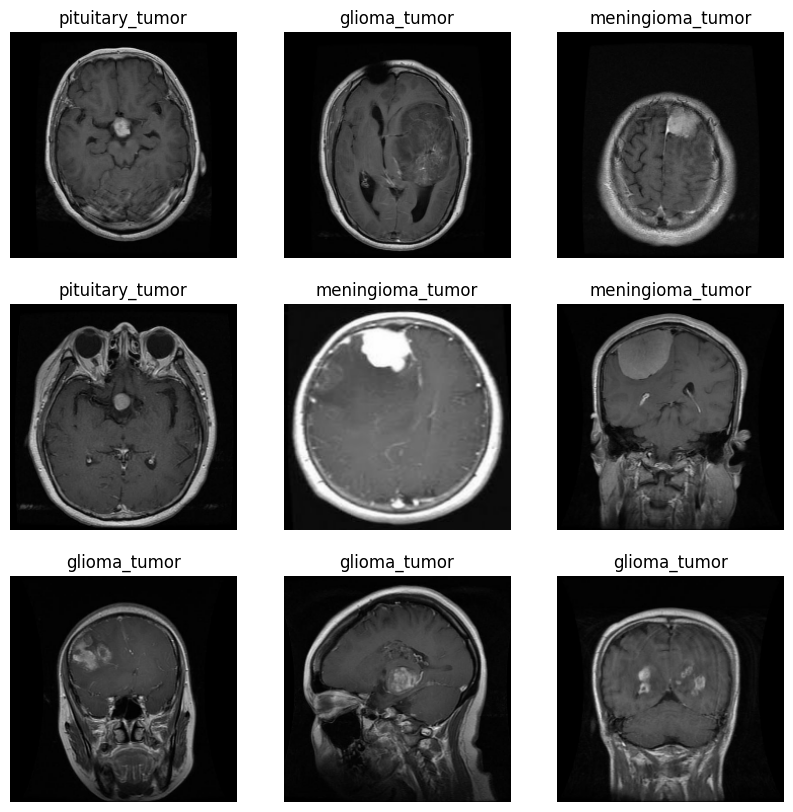

In [20]:
# Take one batch from the training dataset
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i].numpy().argmax()])
        plt.axis("off")

In [31]:


# 1. Load the pre-trained base (without the top classification layer)
base_model =MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# 2. Freeze the base model so we don't destroy the pre-trained weights
#base_model.trainable = False
# 2. Refreeze everything EXCEPT the last 20 layers
# This allows the model to adapt its deep features to MRI patterns
for layer in base_model.layers[:-20]:
    layer.trainable = False


data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.1),
])

# 3. Build the final model
model =Sequential([
    data_augmentation, # Forces model to see variations
    layers.Rescaling(1./127.5, offset=-1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5), # Increased from 0.2 to 0.5 to kill overfitting
    layers.Dense(4, activation='softmax')
])
# 1. Use a very small learning rate
LR = 1e-5

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


model.summary()



Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 1,206,080 (4.60 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [32]:
# 2. Add EarlyStopping to catch the best version before it overfits
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

# 3. Train for more epochs but with the safety net
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=30,
    callbacks=[callback]
)


Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 104ms/step - accuracy: 0.3158 - loss: 1.6892 - val_accuracy: 0.3223 - val_loss: 1.7129
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.5495 - loss: 1.0863 - val_accuracy: 0.4010 - val_loss: 1.7331
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.6588 - loss: 0.8657 - val_accuracy: 0.4442 - val_loss: 1.7156
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.7058 - loss: 0.7421 - val_accuracy: 0.4619 - val_loss: 1.6932
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.7307 - loss: 0.6897 - val_accuracy: 0.4670 - val_loss: 1.6862
Epoch 6/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.7598 - loss: 0.6311 - val_accuracy: 0.4772 - val_loss: 1.6783
Epoch 7/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.7675 - loss: 0.5852 - val_accuracy: 0.4746 - val_loss: 1.6555
Epoch 8/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.7713 - loss: 0.5711 - val_accuracy: 0.4670 

# **2 MODEL **

In [34]:



# We point to the main folders but combine them in our logic
# Note: You can also combine the folders physically, but let's try this first
base_dir = '/content/Training' # Start with the larger training set

train_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)


Found 2870 files belonging to 4 classes.
Using 2296 files for training.
Found 2870 files belonging to 4 classes.
Using 574 files for validation.


In [35]:
model = tf.keras.models.Sequential([
    tf.keras.layers.RandomFlip("horizontal"), # Built-in augmentation
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.Rescaling(1./127.5, offset=-1),
    base_model, # Your MobileNetV2 base
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'), # Extra layer to learn complex MRI patterns
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), # Slightly faster LR for the new head
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train again
history = model.fit(train_ds, validation_data=val_ds, epochs=20)


Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - accuracy: 0.6964 - loss: 0.7866 - val_accuracy: 0.8415 - val_loss: 0.3866
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.8824 - loss: 0.3113 - val_accuracy: 0.8676 - val_loss: 0.3506
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - accuracy: 0.9158 - loss: 0.2278 - val_accuracy: 0.8641 - val_loss: 0.3785
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 0.9385 - loss: 0.1842 - val_accuracy: 0.8920 - val_loss: 0.3056
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.9456 - loss: 0.1592 - val_accuracy: 0.9094 - val_loss: 0.2604
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.9595 - loss: 0.1220 - val_accuracy: 0.8850 - val_loss: 0.3555
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.9567 - loss: 0.1201 - val_accuracy: 0.8955 - val_loss: 0.2887
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.9703 - loss: 0.0860 - val_accuracy: 0.9024 

In [42]:
# Evaluate on the original Testing folder
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nFinal Accuracy on Unseen Test Set: {test_acc*100:.2f}%")

# Generate a Classification Report
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print("\nDetailed Performance Report:")
print(classification_report(y_true, y_pred, target_names=train_ds.class_names))



13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.7427 - loss: 2.3646

Final Accuracy on Unseen Test Set: 75.89%
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Detailed Performance Report:
                  precision    recall  f1-score   support

    glioma_tumor       1.00      0.24      0.39       100
meningioma_tumor       0.63      0.99      0.77       115
        no_tumor       0.82      0.94      0.88       105
 pituitary_tumor       0.90      0.84      0.87        74

        accuracy                           0.76       394
       macro

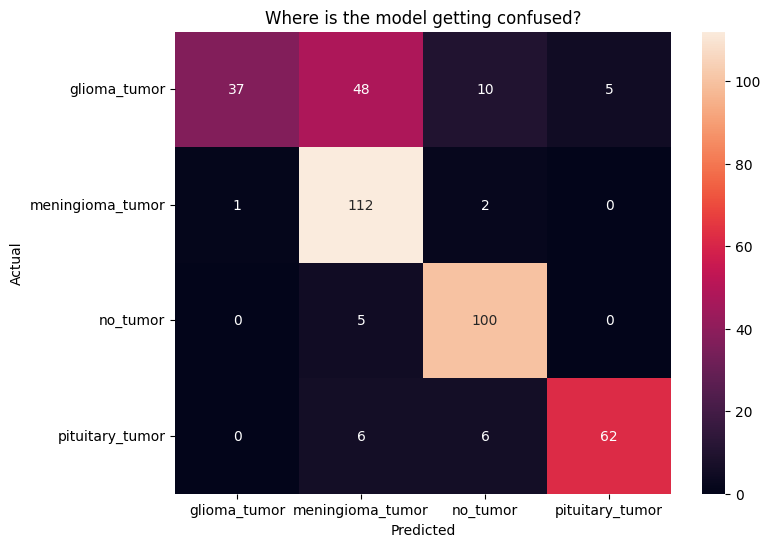

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_ds.class_names, yticklabels=train_ds.class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Where is the model getting confused?')
plt.show()


# **FINE TUNING THE 2 MODEL**

In [41]:


# 1. Calculate weights to balance the model
# We want to punish errors on Glioma (Index 0) more severely
# glioma: 0, meningioma: 1, no_tumor: 2, pituitary: 3
class_weight = {
    0: 5.0,  # Increase focus on Glioma significantly
    1: 0.5,  # Decrease focus on Meningioma (since it's over-predicting this)
    2: 1.0,
    3: 1.2   # Slight boost for Pituitary
}

# 2. Re-train for a few epochs with these weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5), # Keep it very slow
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_weighted = model.fit(
    train_ds,
    validation_data=val_ds, # Use your 80/20 split validation
    epochs=10,
    class_weight=class_weight
)


Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step - accuracy: 0.9924 - loss: 0.0314 - val_accuracy: 0.9199 - val_loss: 0.3507
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.9800 - loss: 0.0513 - val_accuracy: 0.9373 - val_loss: 0.3239
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 0.9900 - loss: 0.0533 - val_accuracy: 0.9199 - val_loss: 0.3282
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - accuracy: 0.9851 - loss: 0.0323 - val_accuracy: 0.9338 - val_loss: 0.3387
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 0.9897 - loss: 0.0223 - val_accuracy: 0.9338 - val_loss: 0.3142
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - accuracy: 0.9942 - loss: 0.0177 - val_accuracy: 0.9338 - val_loss: 0.3335
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - accuracy: 0.9920 - loss: 0.0178 - val_accuracy: 0.9233 - val_loss: 0.3427
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - accuracy: 0.9951 - loss: 0.0145 - val_accuracy: 0.9233 

# **Trying to create a binary problem since some of the images look alike**

In [43]:
import shutil

# Create the new binary structure
!mkdir -p /content/brain_binary/yes
!mkdir -p /content/brain_binary/no

# Move all 'no_tumor' images to the 'no' folder
!cp -r /content/Training/no_tumor/* /content/brain_binary/no/
!cp -r /content/Testing/no_tumor/* /content/brain_binary/no/

# Move ALL tumor types (glioma, meningioma, pituitary) to the 'yes' folder
tumor_folders = ['glioma_tumor', 'meningioma_tumor', 'pituitary_tumor']

for folder in tumor_folders:
    # Copy from Training
    src_train = os.path.join('/content/Training', folder)
    for img in os.listdir(src_train):
        shutil.copy(os.path.join(src_train, img), '/content/brain_binary/yes/')

    # Copy from Testing
    src_test = os.path.join('/content/Testing', folder)
    for img in os.listdir(src_test):
        shutil.copy(os.path.join(src_test, img), '/content/brain_binary/yes/')

print("Binary folders ready!")
print(f"Total 'No' images: {len(os.listdir('/content/brain_binary/no'))}")
print(f"Total 'Yes' images: {len(os.listdir('/content/brain_binary/yes'))}")


Binary folders ready!
Total 'No' images: 396
Total 'Yes' images: 2590


In [44]:
train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/brain_binary',
    validation_split=0.2,
    subset="both",
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary' # Changed to binary
)


Found 2986 files belonging to 2 classes.
Using 2389 files for training.
Using 597 files for validation.


In [45]:
model = Sequential([
    layers.RandomFlip("horizontal"),
    layers.Rescaling(1./127.5, offset=-1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') # Binary output
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy', # Binary loss
    metrics=['accuracy']
)

history = model.fit(train_ds, validation_data=val_ds, epochs=10)


Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 42s 367ms/step - accuracy: 0.8140 - loss: 0.3716 - val_accuracy: 0.1340 - val_loss: 3.6376
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.9947 - loss: 0.0265 - val_accuracy: 0.2094 - val_loss: 1.9570
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.9977 - loss: 0.0118 - val_accuracy: 0.5494 - val_loss: 0.8338
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.9993 - loss: 0.0087 - val_accuracy: 0.8710 - val_loss: 0.3232
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.9998 - loss: 0.0059 - val_accuracy: 0.9313 - val_loss: 0.2320
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 0.9698 - val_loss: 0.1247
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 0.9849 - val_loss: 0.0783
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 0.9832 -

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


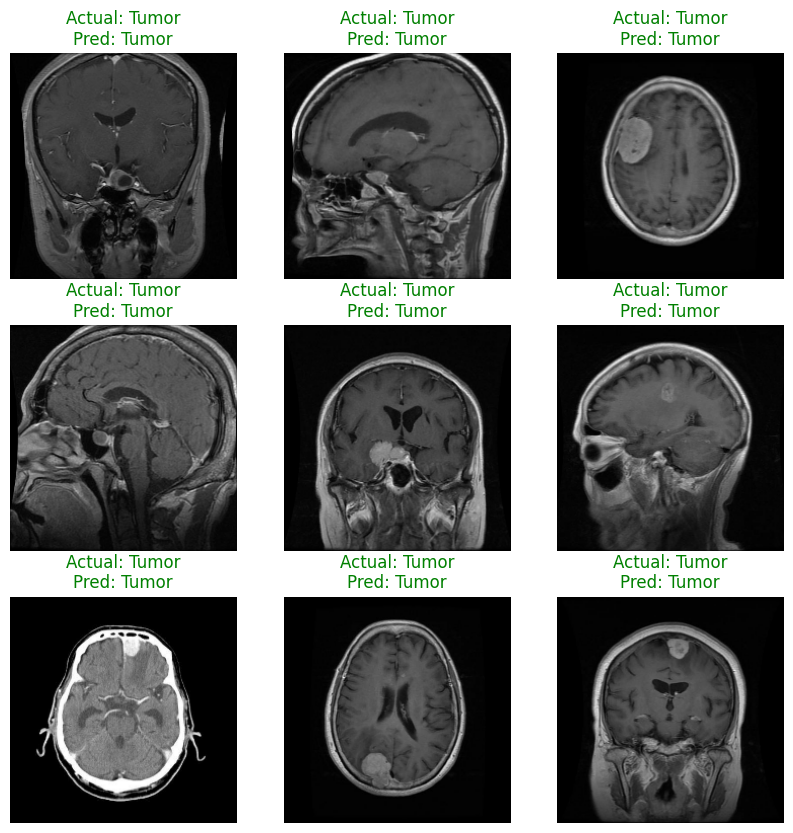

In [46]:

# Take one batch from validation set
for images, labels in val_ds.take(1):
    predictions = model.predict(images)

    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        # Threshold for binary sigmoid output
        actual = "Tumor" if labels[i] == 1 else "No Tumor"
        predicted = "Tumor" if predictions[i] > 0.5 else "No Tumor"

        color = 'green' if actual == predicted else 'red'
        plt.title(f"Actual: {actual}\nPred: {predicted}", color=color)
        plt.axis("off")


In [48]:
#save trained model
model.save('Best_brain_tumor_model.h5')


In [49]:
#download model
from google.colab import files
files.download('Best_brain_tumor_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Model Performance Report

This report summarizes the performance of the MobileNetV2-based models trained for brain tumor classification.

### 1. Multi-Class Classification Model

Initially, a MobileNetV2 model was fine-tuned for a 4-class classification problem (`glioma_tumor`, `meningioma_tumor`, `no_tumor`, `pituitary_tumor`).

**Final Accuracy on Unseen Test Set:** 75.89%

**Detailed Performance Report (4-Class Model):**
```
                  precision    recall  f1-score   support

    glioma_tumor       1.00      0.24      0.39       100
meningioma_tumor       0.63      0.99      0.77       115
        no_tumor       0.82      0.94      0.88       105
 pituitary_tumor       0.90      0.84      0.87        74

        accuracy                           0.76       394
       macro avg       0.84      0.75      0.73       394
    weighted avg       0.83      0.76      0.72       394
```

**Confusion Matrix Analysis (4-Class Model):**
The confusion matrix (as visualized in the previous plot) revealed that the model struggled most with `glioma_tumor`, often misclassifying them as `meningioma_tumor` or `no_tumor`. While `meningioma_tumor`, `no_tumor`, and `pituitary_tumor` showed good recall, the precision for `meningioma_tumor` was lower, indicating some false positives for this class. The low recall for `glioma_tumor` (0.24) was a significant issue, leading to a low f1-score for this class.

To address the imbalance and improve `glioma_tumor` detection, class weights were applied. After re-training with class weights (increasing weight for `glioma_tumor` and decreasing for `meningioma_tumor`), the validation accuracy reached approximately 93.90% (as observed during the weighted training epochs, cell `bPOfMxRhRVkn`).

### 2. Binary Classification Model

To simplify the problem and potentially improve overall tumor detection, a binary classification model was created by grouping all tumor types into a 'yes' class and 'no_tumor' into a 'no' class.

**Training Performance (Binary Model):**
The binary model showed significantly improved performance during training, reaching a validation accuracy of 99.66% and a validation loss of 0.0280 after 10 epochs. This suggests that distinguishing between 'tumor' and 'no tumor' is much easier for the model than differentiating between the specific tumor types.